# B Corp Performance Analysis

This notebook explores B Corp company performance using assessment-level data.

The goal is to understand:
- how company scores evolve over time  
- whether improvement is linked to certification retention  
- how company size influences outcomes  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/bcorp_score_dataset.csv")

df.head()

,company_id,company_name,date_first_certified,date_certified,current_status,description,industry,industry_category,products_and_services,country,...,ia_workers_it_human_rights_labor_policy,ia_workers_it_job_flexibility_corporate_culture,ia_workers_it_management_worker_communication,ia_workers_it_occupational_health_safety,ia_workers_it_training_education,ia_workers_it_worker_benefits,ia_workers_it_worker_owned,ia_workers_it_worker_ownership,ia_workers_it_workforce_development,certification_cycle
0,0013b00001rId9LAAS,Arch Textiles Manufacture Corp.,2021-02-24,2024-05-13,certified,"Established over a decade ago in Shanghai, Chi...",Textiles,Manufactured Goods,Textile Manufacturing,China,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,0013b00001rId9LAAS,Arch Textiles Manufacture Corp.,2021-02-24,2021-02-24,certified,"Established over a decade ago in Shanghai, Chi...",Textiles,Manufactured Goods,Textile Manufacturing,China,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
2,001C000001R0tn1IAB,kria,2016-06-29,2019-12-02,de-certified,Kria is a Brazilian equity crowdfunding platfo...,Other financial services,Financial & insurance activities,Online investment platform for startups - Plat...,Brazil,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,001C000001R0tn1IAB,kria,2016-06-29,2016-06-29,de-certified,Kria is a Brazilian equity crowdfunding platfo...,Other financial services,Financial & insurance activities,Online investment platform for startups - Plat...,Brazil,...,0.8,NaN,3.2,2.0,3.8,6.0,NaN,6.0,NaN,2.0
4,0013b00001zXx0fAAC,Ocean Design,2023-11-01,2023-11-07,certified,"Te oranga o te tāngata, he whenua, he moana.\n...",Advertising & market research,Professional & technical services,NaN,New Zealand,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [4]:
df.shape
df.columns
df.describe()

,assessment_year,overall_score,impact_area_community,impact_area_customers,impact_area_environment,impact_area_governance,impact_area_workers,impact_area_community_na_score,impact_area_customers_na_score,impact_area_environment_na_score,...,ia_workers_it_human_rights_labor_policy,ia_workers_it_job_flexibility_corporate_culture,ia_workers_it_management_worker_communication,ia_workers_it_occupational_health_safety,ia_workers_it_training_education,ia_workers_it_worker_benefits,ia_workers_it_worker_owned,ia_workers_it_worker_ownership,ia_workers_it_workforce_development,certification_cycle
count,22613.000000,22613.000000,22613.000000,22255.000000,22613.000000,22613.000000,20721.000000,22613.000000,22255.000000,22613.000000,...,905.000000,2228.000000,4884.000000,1739.000000,4073.000000,2142.000000,440.000000,4665.000000,1023.000000,22613.000000
mean,2020.210189,95.976770,24.626365,11.920741,16.697798,15.062327,24.470610,1.666922,0.047675,1.376456,...,0.709392,1.769120,3.165315,1.036343,1.543825,6.851401,16.030455,2.682594,15.433822,1.591076
std,3.509999,15.453251,12.920309,14.002481,12.296843,3.919845,8.858465,1.484195,0.265348,2.367729,...,0.428325,1.002802,2.078912,0.724693,1.136383,3.246091,13.009050,1.978370,12.692901,0.937213
min,2007.000000,74.900000,0.700000,0.000000,0.000000,1.900000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000,1.000000
25%,2018.000000,84.400000,16.200000,2.800000,7.200000,13.000000,19.500000,0.000000,0.000000,0.000000,...,0.400000,1.000000,1.600000,0.600000,0.800000,4.500000,0.000000,1.800000,4.900000,1.000000
50%,2021.000000,91.400000,20.500000,4.500000,12.200000,15.600000,24.100000,1.600000,0.000000,0.400000,...,0.800000,1.800000,2.600000,1.100000,1.300000,6.900000,21.300000,2.600000,13.300000,1.000000
75%,2023.000000,102.700000,29.000000,18.600000,24.500000,17.700000,29.000000,2.700000,0.000000,1.500000,...,1.100000,2.500000,4.200000,1.300000,2.100000,9.175000,28.800000,3.000000,23.850000,2.000000
max,2026.000000,214.300000,125.400000,93.000000,93.100000,41.300000,89.000000,10.800000,8.800000,22.900000,...,1.600000,5.300000,14.400000,7.700000,12.000000,21.300000,30.000000,19.500000,61.800000,8.000000


In [6]:
# eliminar valores inválidos de size
df = df[df['size'] != '0']

# convertir fecha
df['date_certified'] = pd.to_datetime(df['date_certified'])

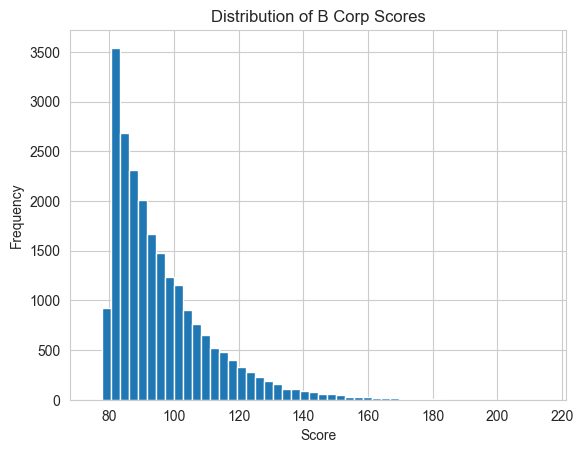

In [7]:
plt.figure()
df['overall_score'].hist(bins=50)
plt.title("Distribution of B Corp Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

Most companies cluster around the certification threshold, suggesting that many firms operate close to the minimum required score.